# load dataset

In [ ]:
import pandas as pd
import re
import nltk
import spacy
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

In [ ]:
data1 = pd.read_csv('mail_data.csv', encoding='latin-1')
data2 = pd.read_csv('Phishing_Email.csv', encoding='utf-8', on_bad_lines='skip', engine='python')


In [ ]:
data1

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ã¼ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [ ]:
data2.drop(['Unnamed: 0'], axis =1)

,Email Text,Email Type
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,the other side of * galicismos * * galicismo *...,Safe Email
2,re : equistar deal tickets are you still avail...,Safe Email
3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,software at incredibly low prices ( 86 % lower...,Phishing Email
...,...,...
14544,great x - mass gift travel news > > an amazing...,Phishing Email
14545,low price software http : / / neonate . setupm...,Phishing Email
14546,"re : 6 . 775 , syldavian tutorial there is one...",Safe Email
14547,attn : i presume this mail will not be a surpr...,Phishing Email


# pre-processing

In [ ]:
import re

def preprocessing(msg):
    if not isinstance(msg, str):
        msg = str(msg)
    msg = clean_text(msg)
    msg = remove_special_characters(msg)
    msg = remove_numbers(msg)
    msg = remove_extra_spaces(msg)
    msg = remove_short_text(msg)
    msg = remove_emojis(msg)
    return msg

def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = text.lower()
    return text

def remove_special_characters(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

def remove_numbers(text):
    text = re.sub(r'\d+', '', text)
    return text

def remove_extra_spaces(text):
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def remove_short_text(text, min_length=10):
    return text if len(text) >= min_length else ''

def remove_emojis(text):
    emoji_pattern = re.compile("[\U00010000-\U0010ffff]", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

data1['Message'] = data1['Message'].apply(preprocessing)
data1 = data1[data1['Message'] != '']

data2['Email Text'] = data2['Email Text'].apply(preprocessing)
data2 = data2[data2['Email Text'] != '']


In [ ]:
data1['Spam'] = data1['Category'].map({'spam': 1, 'ham': 0})
data1.drop(['Category'],axis = 1)

<ipython-input-8-2d2c8277abed>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['Spam'] = data1['Category'].map({'spam': 1, 'ham': 0})


,Message,Spam
0,go until jurong point crazy available only in ...,0
1,ok lar joking wif u oni,0
2,free entry in a wkly comp to win fa cup final ...,1
3,u dun say so early hor u c already then say,0
4,nah i dont think he goes to usf he lives aroun...,0
...,...,...
5567,this is the nd time we have tried contact u u ...,1
5568,will b going to esplanade fr home,0
5569,pity was in mood for that soany other suggestions,0
5570,the guy did some bitching but i acted like id ...,0


In [ ]:
#data2['Phishing'] = data2['Email Type'].map({'Phishing Email': 1, 'Safe Email': 0}).fillna(-1)
data2 = data2[['Email Text', 'Phishing']]
data2

,Email Text,Phishing
0,re disc uniformitarianism re sex lang dick hud...,0.0
1,the other side of galicismos galicismo is a sp...,0.0
2,re equistar deal tickets are you still availab...,0.0
3,hello i am your hot lil horny toy i am the one...,1.0
4,software at incredibly low prices lower draper...,1.0
...,...,...
14544,great x mass gift travel news an amazing night...,1.0
14545,low price software http neonate setupmefree com a,1.0
14546,re syldavian tutorial there is one at least tr...,0.0
14547,attn i presume this mail will not be a surpris...,1.0


stopword

In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

slang_dict = {
    "u": "you",
    "ur": "your",
    "r": "are",
    "2": "to",
    "4": "for",
    "pls": "please",
    "plz": "please",
    "wif": "with",
    "dun": "don't",
    "wat": "what",
    "lar": "lah",
    "oni": "only",
    "tkts": "tickets",
    "n": "and",
    "c": "see",
    "b4": "before",
    "msg": "message",
    "txt": "text",
    "wkly": "weekly",
    "comp": "competition",
    "fa": "football association",
    "lil" : "little",
    "disc": "discount",

}


def process2_text(text, slang_dict):
    def replace_slang(text, slang_dict):
        words = text.split()
        replaced = [slang_dict.get(word, word) for word in words]  # Ganti slang jika ada di kamus
        return ' '.join(replaced)

    def remove_stopwords(text):
        words = text.split()
        filtered = [word for word in words if word not in stop_words]  # Hapus stopwords
        return ' '.join(filtered)

    def lemmatize_text(text):
        words = text.split()
        lemmatized = [lemmatizer.lemmatize(word) for word in words]  # Lemmatizing
        return ' '.join(lemmatized)

    # Pipeline pembersihan teks
    text = clean_text(text)
    text = replace_slang(text, slang_dict)
    text = remove_stopwords(text)
    text = lemmatize_text(text)
    return text

data1['Message'] = data1['Message'].apply(lambda x: process2_text(str(x), slang_dict))

data2['Message'] = data2['Email Text'].apply(lambda x: process2_text(str(x), slang_dict))
# data2[['Message']].head()
data1[['Message']].head()


<ipython-input-14-720646bc3297>:59: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data1['Message'] = data1['Message'].apply(lambda x: process2_text(str(x), slang_dict))


,Message
0,go jurong point crazy available bugis great wo...
1,ok lah joking
2,free entry weekly competition win football ass...
3,say early hor see already say
4,nah dont think go usf life around though


In [ ]:
data2 = data2[['Message', 'Phishing']]
data2

,Message,Phishing
0,discount uniformitarianism sex lang dick hudso...,0.0
1,side galicismos galicismo spanish term name im...,0.0
2,equistar deal ticket still available assist ro...,0.0
3,hello hot little horny toy one dream open mind...,1.0
4,software incredibly low price lower drapery se...,1.0
...,...,...
14544,great x mass gift travel news amazing night fl...,1.0
14545,low price software http neonate setupmefree com,1.0
14546,syldavian tutorial one least translation oldes...,0.0
14547,attn presume mail surprise accountant ministry...,1.0


In [ ]:
data1 = data1[['Message', 'Spam']]
data1

,Message,Spam
0,go jurong point crazy available bugis great wo...,0
1,ok lah joking,0
2,free entry weekly competition win football ass...,1
3,say early hor see already say,0
4,nah dont think go usf life around though,0
...,...,...
5567,nd time tried contact pound prize claim easy c...,1
5568,b going esplanade fr home,0
5569,pity mood soany suggestion,0
5570,guy bitching acted like id interested buying s...,0


In [ ]:
d1 = data1
d1.to_csv('Spam after preprocessing.csv', index=False)

In [ ]:
d2 = data2
d2.to_csv('Phising after prprocesiing.csv', index=False)

# EDA spam

In [ ]:
spam_messages = d1[d1['Spam'] == 1]['Message']
ham_messages = d1[d1['Spam'] == 0]['Message']
print("Jumlah pesan spam:", len(spam_messages))
print("Jumlah pesan ham:", len(ham_messages))

Jumlah pesan spam: 743
Jumlah pesan ham: 4754


In [ ]:
import pandas as pd

# Asumsikan d1 adalah DataFrame asli Anda dengan kolom 'Message' dan 'Spam'
# Asumsikan d1_smote telah dibuat menggunakan SMOTE dan memiliki beberapa pesan kosong.

# 1. Identifikasi Data Spam
data_spam = d1[d1['Spam'] == 1]

# 2. Hitung Berapa Banyak Data yang Perlu Diduplikasi
#    Kita akan duplikasi sampai jumlah data spam sama dengan jumlah data ham
jumlah_data_ham = len(d1[d1['Spam'] == 0])
jumlah_data_spam = len(data_spam)
jumlah_duplikasi = jumlah_data_ham - jumlah_data_spam

# 3. Duplikasi Data Spam (Jika diperlukan)
if jumlah_duplikasi > 0:
    data_spam_didup = pd.concat([data_spam] * (jumlah_duplikasi // jumlah_data_spam + 1), ignore_index=True)
    data_spam_didup = data_spam_didup.iloc[:jumlah_duplikasi]  # Ambil data sesuai jumlah duplikasi

    # 4. Gabungkan Data yang Diduplikasi ke Data Asli
    d1_oversampled = pd.concat([d1, data_spam_didup], ignore_index=True)
else:
    d1_oversampled = d1.copy()
# 5. hapus pesan kosong

d1_oversampled = d1_oversampled.dropna(subset=['Message'])
d1_oversampled = d1_oversampled[d1_oversampled['Message'] != '']

print("Jumlah data sebelum oversampling:", len(d1))
print("Jumlah data setelah oversampling:", len(d1_oversampled))
print("Jumlah data Spam:",len(d1_oversampled[d1_oversampled['Spam'] == 1]))
print("Jumlah data Ham:", len(d1_oversampled[d1_oversampled['Spam'] == 0]))

print(d1_oversampled[['Message', 'Spam']])

Jumlah data sebelum oversampling: 5497
Jumlah data setelah oversampling: 9502
Jumlah data Spam: 4754
Jumlah data Ham: 4748
                                                Message  Spam
0     go jurong point crazy available bugis great wo...     0
1                                         ok lah joking     0
2     free entry weekly competition win football ass...     1
3                         say early hor see already say     0
4              nah dont think go usf life around though     0
...                                                 ...   ...
9503  sm service inclusive text credit please goto w...     1
9504  freeday sexy st george day pic jordantxt pic d...     1
9505  winner specially selected receive cash award s...     1
9506  sunshine hols claim med holiday send stamped s...     1
9507  win music gift voucher every week starting tex...     1

[9502 rows x 2 columns]


train test split (lewati)

In [ ]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np

# Assuming d1 is your DataFrame containing 'Message' and 'Spam' columns
# d1 is defined before in your notebook

# Pisahkan fitur (X) dan label (y)
X = d1['Message']  # Now X is a Series of text messages
y = d1['Spam']

# Inisialisasi CountVectorizer
vectorizer = CountVectorizer()

# Fit dan transform data teks
X_vectorized = vectorizer.fit_transform(X)  # X is used here, not X['Message']

# Inisialisasi SMOTE
smote = SMOTE(random_state=42)

# Terapkan SMOTE untuk oversampling
X_smote, y_smote = smote.fit_resample(X_vectorized, y)  # X_vectorized is used here

# Konversi hasil resampled kembali ke DataFrame dan Series
X_smote = pd.DataFrame(X_smote.toarray(), columns=vectorizer.get_feature_names_out())
y_smote = pd.Series(y_smote, name='Spam')

# Gabungkan kembali X_smote dan y_smote menjadi DataFrame baru
d1_smote = pd.concat([X_smote, y_smote], axis=1)

#menambahkan kolom Message
def inverse_transform_row(row):
    row_array = np.array(row).reshape(1, -1)
    return ' '.join(vectorizer.inverse_transform(row_array)[0])

# Tambahkan kembali kolom Message setelah SMOTE
d1_smote['Message'] = d1_smote[vectorizer.get_feature_names_out()].apply(inverse_transform_row, axis=1)

# Reorder columns to match the initial d1
d1_smote = d1_smote[['Message', 'Spam'] + [col for col in d1_smote.columns if col not in ['Message', 'Spam']]]
print(d1_smote[['Message', 'Spam']])

/usr/local/lib/python3.10/dist-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/utils/_tags.py:354: FutureWarning: The SMOTE or classes from which it inherits use `_get_tags` and `_more_tags`. Please define the `__sklearn_tags__` method, or inherit from `sklearn.base.BaseEstimator` and/or other appropriate mixins such as `sklearn.base.TransformerMixin`, `sklearn.base.ClassifierMixin`, `sklearn.base.RegressorMixin`, and `sklearn.base.OutlierMixin`. From scikit-learn 1.7, not defining `__sklearn_tags__` will raise an error.
  warnings.warn(


                                                Message  Spam
0     amore available buffet bugis cine crazy go got...     0
1                                         joking lah ok     0
2     apply association competition cup entry final ...     1
3                             already early hor say see     0
4              around dont go life nah think though usf     0
...                                                 ...   ...
9503  call camera colour free freefone latest mobile...     1
9504                                              price     1
9505                                                        1
9506                                            bid end     1
9507  call camera co colour entitled free latest mob...     1

[9508 rows x 2 columns]


In [ ]:
import pandas as pd

# Asumsikan d1_smote sudah didefinisikan (DataFrame hasil dari SMOTE)

# Periksa dan hitung pesan kosong
jumlah_pesan_kosong = (d1_smote['Message'] == '').sum()

# Tampilkan jumlah pesan kosong
print(f"Jumlah pesan kosong dalam d1_smote: {jumlah_pesan_kosong}")

# Untuk melihat baris mana saja yang kosong:
pesan_kosong = d1_smote[d1_smote['Message'] == '']
print("\nBaris dengan pesan kosong:")
print(pesan_kosong[['Message', 'Spam']]) #hanya menampilkan kolom message dan spam

Jumlah pesan kosong dalam d1_smote: 826

Baris dengan pesan kosong:
     Message  Spam
1540             0
3094             0
3659             0
3732             0
4514             0
...      ...   ...
9485             1
9487             1
9499             1
9502             1
9505             1

[826 rows x 2 columns]


In [ ]:
!pip install imbalanced-learn==0.11.0

# modeling using BoW

membuat kosa kata

In [ ]:
d1_oversampled['Spam'].value_counts()

,count
Spam,
1,4754
0,4748


In [ ]:
import random
import random
d1_oversampled_shuffled = d1_oversampled.sample(frac=1, random_state=42).reset_index(drop=True)

# Tentukan indeks untuk split
split_index = int(0.8 * len(d1_oversampled_shuffled))

# Split dataset menjadi train dan test
trainih= d1_oversampled_shuffled.iloc[:split_index]
testnih = d1_oversampled_shuffled.iloc[split_index:]
print("Jumlah data train:", len(trainih))
print("Jumlah data test:", len(testnih))


Jumlah data train: 7601
Jumlah data test: 1901


pemisahan spam dan ham

In [ ]:
spam_messages = d1_oversampled_shuffled[d1_oversampled_shuffled['Spam'] == 1]['Message']
ham_messages = d1_oversampled_shuffled[d1_oversampled_shuffled['Spam'] == 0]['Message']
print("Jumlah pesan spam:", len(spam_messages))
print("Jumlah pesan ham:", len(ham_messages))

Jumlah pesan spam: 4754
Jumlah pesan ham: 4748


frekuensi kata

In [ ]:
from collections import defaultdict
ham_word_counts = defaultdict(int)
spam_word_counts = defaultdict(int)

total_spam_words = 0
total_ham_words = 0

for message in spam_messages:
    for word in message.split():
        spam_word_counts[word] += 1
        total_spam_words += 1

for message in ham_messages:
    for word in message.split():
        ham_word_counts[word] += 1
        total_ham_words += 1
print("Kata dalam Spam:", dict(spam_word_counts))
print("Kata dalam Ham:", dict(ham_word_counts))
print("Total Kata Spam:", total_spam_words)
print("Total Kata Ham:", total_ham_words)

Kata dalam Spam: {'hi': 116, 'ya': 6, 'babe': 62, 'x': 78, 'goten': 6, 'bout': 6, 'scammer': 6, 'getting': 27, 'smartthough': 6, 'regular': 6, 'vodafone': 38, 'respond': 6, 'get': 530, 'prem': 6, 'rate': 183, 'msgsubscription': 6, 'no': 6, 'used': 6, 'also': 18, 'beware': 6, 'money': 26, 'wining': 6, 'number': 245, 'wot': 6, 'next': 103, 'free': 1397, 'entry': 171, 'grprizes': 6, 'weekly': 245, 'competition': 71, 'chance': 186, 'win': 400, 'latest': 234, 'nokia': 442, 'psp': 6, 'cash': 398, 'every': 214, 'wktxt': 6, 'great': 67, 'httpwwwgrprizescom': 6, 'dear': 104, 'dave': 13, 'final': 104, 'notice': 19, 'collect': 137, 'tenerife': 47, 'holiday': 204, 'award': 188, 'call': 2284, 'landline': 217, 'tc': 320, 'sae': 133, 'box': 311, 'cwwx': 27, 'ppm': 265, 'good': 76, 'luck': 38, 'draw': 238, 'take': 115, 'place': 31, 'th': 32, 'feb': 6, 'removal': 12, 'send': 433, 'stop': 750, 'customer': 325, 'service': 462, 'video': 188, 'camera': 208, 'phone': 374, 'half': 83, 'price': 116, 'line': 2

In [ ]:
vocabulary = set(" ".join(d1_oversampled['Message']).split())
vocab_size = len(vocabulary)


prior probability

In [ ]:
p_spam_train = len(spam_messages) / len(trainih)
p_ham_train= len(ham_messages) / len(trainih) #prior probability
print("Prior Probability Spam:", p_spam_train)
print("Prior Probability Ham:", p_ham_train)

Prior Probability Spam: 0.6254440205236154
Prior Probability Ham: 0.6246546507038547


conditional probability

In [ ]:

def calculate_word_probabilities(word_counts, total_words, vocab_size):
    probabilities = {}
    for word in vocabulary:
        probabilities[word] = (word_counts[word] + 1) / (total_words + vocab_size)  # Laplace smoothing
    return probabilities
spam_word_probs = calculate_word_probabilities(spam_word_counts, total_spam_words, vocab_size) #conditional probability
ham_word_probs= calculate_word_probabilities(ham_word_counts, total_ham_words, vocab_size)
print("Conditional Probability Spam:", spam_word_probs)
print("Conditional Probability Ham:", ham_word_probs)


Conditional Probability Spam: {'selfindependence': 1.353070116093416e-05, 'weirdo': 1.353070116093416e-05, 'dha': 1.353070116093416e-05, 'pout': 1.353070116093416e-05, 'set': 0.00010824560928747328, 'becoz': 1.353070116093416e-05, 'txtin': 0.0003653289313452223, 'end': 0.0017995832544042433, 'epi': 1.353070116093416e-05, 'newport': 1.353070116093416e-05, 'poortiyagi': 1.353070116093416e-05, 'lara': 1.353070116093416e-05, 'wwwcom': 0.00018942981625307822, 'stchoicecouk': 0.00010824560928747328, 'forget': 0.00018942981625307822, 'liaoso': 1.353070116093416e-05, 'witout': 1.353070116093416e-05, 'dime': 1.353070116093416e-05, 'thmarch': 0.00010824560928747328, 'various': 0.00010824560928747328, 'stu': 1.353070116093416e-05, 'honeybee': 1.353070116093416e-05, 'evrydy': 1.353070116093416e-05, 'polo': 0.00017589911509214407, 'gt': 1.353070116093416e-05, 'fletcher': 1.353070116093416e-05, 'itor': 1.353070116093416e-05, 'brin': 1.353070116093416e-05, 'decimal': 1.353070116093416e-05, 'themed': 

In [ ]:
import numpy as np
def predict_naive_bayes(message):
    perkata = message.split()

    spam_prob = np.log(p_spam_train)  #di log biarv mencegah underflow, dan prior probability yang sebelumnya, jadi harusnya p_spam_train
    ham_prob = np.log(p_ham_train)

    for kata in perkata:
        spam_prob += np.log(spam_word_probs.get(kata, 1 / (total_spam_words + vocab_size))) #p (word |spam), jika tidak ada maka menggunakan laplace smoothing
        ham_prob += np.log(ham_word_probs.get(kata, 1 / (total_ham_words + vocab_size)))

        #Jika spam_prob1 lebih besar dari ham_prob1, maka email tersebut diprediksi sebagai spam (return 1).
        #Jika spam_prob1 lebih besar" artinya nilai akhir (setelah log probabilitas dari semua kata ditambahkan)
         #dari spam_prob1 lebih besar daripada nilai akhir dari ham_prob1.
        #Ini menunjukkan bahwa model kita lebih yakin bahwa email tersebut adalah spam.


    return 1 if spam_prob > ham_prob else 0

trainih['Predicted'] = trainih['Message'].apply(predict_naive_bayes)
df_train = trainih[['Message', 'Spam', 'Predicted']]
df_train

<ipython-input-42-682c43143f0a>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trainih['Predicted'] = trainih['Message'].apply(predict_naive_bayes)


,Message,Spam,Predicted
0,hi ya babe x goten bout scammer getting smartt...,1,1
1,okey dokey ill bit sorting stuff,0,0
2,money wining number wot next,1,0
3,free entry grprizes weekly competition chance ...,1,1
4,dear dave final notice collect tenerife holida...,1,1
...,...,...,...
7596,thanks yesterday sir wonderful hope enjoyed bu...,0,0
7597,dnt wnt tlk wid,0,0
7598,gr see message leaving congrats dear school plan,0,0
7599,day euro kickoff kept informed latest news res...,1,1


Akurasi Model: 0.9851335350611762
Laporan Klasifikasi:
               precision    recall  f1-score   support

           0       0.99      0.98      0.99      3802
           1       0.98      0.99      0.99      3799

    accuracy                           0.99      7601
   macro avg       0.99      0.99      0.99      7601
weighted avg       0.99      0.99      0.99      7601



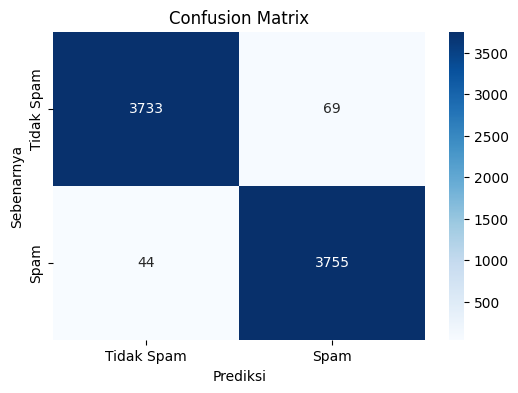

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# evaluasi data train resampled
accuracy = accuracy_score(df_train['Spam'], df_train['Predicted']) #mengubah dari train menjadi train_resampled
print("Akurasi Model:", accuracy)
print("Laporan Klasifikasi:\n", classification_report(df_train['Spam'], df_train['Predicted'])) #mengubah dari train menjadi train_resampled

# Confusion Matrix data train
cm = confusion_matrix(df_train['Spam'], df_train['Predicted']) #mengubah dari train menjadi train_resampled
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Tidak Spam', 'Spam'], yticklabels=['Tidak Spam', 'Spam'])
plt.xlabel('Prediksi')
plt.ylabel('Sebenarnya')
plt.title('Confusion Matrix')
plt.show()


In [ ]:

testnih['Predicted'] = testnih['Message'].apply(predict_naive_bayes)
df_test = testnih[['Message', 'Spam', 'Predicted']]
df_test

<ipython-input-49-4a12fb151e94>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testnih['Predicted'] = testnih['Message'].apply(predict_naive_bayes)


,Message,Spam,Predicted
7601,spoon okay,0,0
7602,rock yr chik get filthy film xxx pic yr phone ...,1,1
7603,dear heroi leaving qatar tonite apt opportunit...,0,0
7604,currently message awaiting collection collect ...,1,1
7605,hot live fantasy call p per min ntt ltd po box...,1,1
...,...,...,...
9497,hi mandy sullivan calling hotmix fmyou chosen ...,1,1
9498,hi darlin kate doin somethin tonight im going ...,0,0
9499,urgent last weekend draw show cash spanish hol...,1,1
9500,hello need posh bird chap user trial prod cham...,1,1


Akurasi Model: 0.98211467648606
Laporan Klasifikasi:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       946
           1       0.98      0.98      0.98       955

    accuracy                           0.98      1901
   macro avg       0.98      0.98      0.98      1901
weighted avg       0.98      0.98      0.98      1901



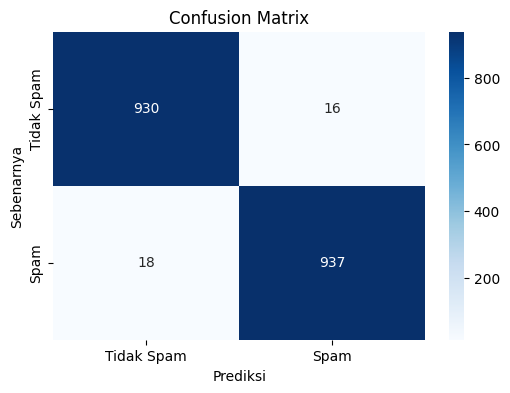

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


accuracy = accuracy_score(df_test['Spam'], df_test['Predicted'])
print("Akurasi Model:", accuracy)
print("Laporan Klasifikasi:\n", classification_report(df_test['Spam'], df_test['Predicted']))

cm = confusion_matrix(df_test['Spam'],df_test['Predicted'])

# Menampilkan confusion matrix dengan seaborn heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Tidak Spam', 'Spam'], yticklabels=['Tidak Spam', 'Spam'])
plt.xlabel('Prediksi')
plt.ylabel('Sebenarnya')
plt.title('Confusion Matrix')
plt.show()


# EDA Phising

In [ ]:
d2['Phishing'].value_counts()

,count
Phishing,
0.0,7446
1.0,4675
-1.0,9


In [ ]:
import pandas as pd

kondisi = d2['Phishing'] != -1.0

d2 = d2[kondisi]

print("Jumlah baris di d2_bersih setelah menghapus -1:", len(d2))
print("Nilai yang unik pada kolom phishing :", d2['Phishing'].unique())
print(d2['Phishing'].value_counts())


Jumlah baris di d2_bersih setelah menghapus -1: 12121
Nilai yang unik pada kolom phishing : [0. 1.]
Phishing
0.0    7446
1.0    4675
Name: count, dtype: int64


In [ ]:
import pandas as pd

# Asumsikan d2 adalah DataFrame asli Anda dengan kolom 'Message' dan 'Phishing'
# dan d1 sudah didefinisikan

# 1. Identifikasi Data Phishing
data_phishing = d2[d2['Phishing'] == 1]

# 2. Hitung Berapa Banyak Data yang Perlu Diduplikasi
jumlah_data_safe = len(d2[d2['Phishing'] == 0])
jumlah_data_phishing = len(data_phishing)
jumlah_duplikasi = jumlah_data_safe - jumlah_data_phishing  #perbaiki disini menjadi jumlah data safe - phishing

# 3. Duplikasi Data Phishing (Jika diperlukan)
if jumlah_duplikasi > 0:
    data_phishing_didup = pd.concat([data_phishing] * (jumlah_duplikasi // jumlah_data_phishing + 1), ignore_index=True)
    data_phishing_didup = data_phishing_didup.iloc[:jumlah_duplikasi]

    # 4. Gabungkan Data yang Diduplikasi ke Data Asli
    d2_oversampled = pd.concat([d2, data_phishing_didup], ignore_index=True) #perbaiki konkatenasi disini
else:
    d2_oversampled = d2.copy()

# 5. Hapus pesan kosong
d2_oversampled = d2_oversampled.dropna(subset=['Message'])
d2_oversampled = d2_oversampled[d2_oversampled['Message'] != '']

print("Jumlah data sebelum oversampling:", len(d2))
print("Jumlah data setelah oversampling:", len(d2_oversampled))
print("Jumlah data Phishing:", len(d2_oversampled[d2_oversampled['Phishing'] == 1])) #perbaiki nama kolom
print("Jumlah data Safe:", len(d2_oversampled[d2_oversampled['Phishing'] == 0])) #perbaiki nama kolom

d2_oversampled = d2_oversampled[['Message', 'Phishing']]
d2_oversampled

Jumlah data sebelum oversampling: 12121
Jumlah data setelah oversampling: 14892
Jumlah data Phishing: 7446
Jumlah data Safe: 7446


,Message,Phishing
0,discount uniformitarianism sex lang dick hudso...,0.0
1,side galicismos galicismo spanish term name im...,0.0
2,equistar deal ticket still available assist ro...,0.0
3,hello hot little horny toy one dream open mind...,1.0
4,software incredibly low price lower drapery se...,1.0
...,...,...
14887,royalization eighteen girl cneoraceous hardcor...,1.0
14888,place online v iagra order know lot profession...,1.0
14889,famous ebay marketing ecourse learn sell compl...,1.0
14890,drip out licking tensor maryland floodlight on...,1.0


In [ ]:
d2_oversampled['Phishing'].value_counts()

,count
Phishing,
0.0,7446
1.0,7446


In [ ]:
import random
import random
d2_oversampled_shuffled = d2_oversampled.sample(frac=1, random_state=42).reset_index(drop=True)

# Tentukan indeks untuk split
split_index = int(0.8 * len(d2_oversampled_shuffled))

# Split dataset menjadi train dan test
trainih= d2.iloc[:split_index]
testnih = d2_oversampled_shuffled.iloc[split_index:]
print("Jumlah data train:", len(trainih))
print("Jumlah data test:", len(testnih))


Jumlah data train: 11913
Jumlah data test: 2979


In [ ]:
Phishing_messages = d2_oversampled_shuffled[d2_oversampled_shuffled['Phishing'] == 1]['Message']
Safe_messages = d2_oversampled_shuffled[d2_oversampled_shuffled['Phishing'] == 0]['Message']
print("Jumlah pesan Phishing:", len(Phishing_messages))
print("Jumlah pesan Safe:", len(Safe_messages))

Jumlah pesan Phishing: 7446
Jumlah pesan Safe: 7446


In [ ]:
from collections import defaultdict
Safe_word_counts = defaultdict(int)
Phishing_word_counts = defaultdict(int)

total_Phishing_words = 0
total_Safe_words = 0

for message in Phishing_messages:
    for word in message.split():
        Phishing_word_counts[word] += 1
        total_Phishing_words += 1

for message in Safe_messages:
    for word in message.split():
        Safe_word_counts[word] += 1
        total_Safe_words += 1
print("Kata dalam Spam:", dict(Phishing_word_counts))
print("Kata dalam Ham:", dict(Safe_word_counts))
print("Total Kata Spam:", total_Phishing_words)
print("Total Kata Ham:", total_Safe_words)

In [ ]:
vocabulary = set(" ".join(d2_oversampled['Message']).split())
vocab_size = len(vocabulary)


prior probability

In [ ]:
p_phishing_train = len(Phishing_messages) / len(trainih)
p_safe_train= len(Safe_messages) / len(trainih) #prior probability
print("Prior Probability Spam:", p_spam_train)
print("Prior Probability Ham:", p_ham_train)

Prior Probability Spam: 0.6254440205236154
Prior Probability Ham: 0.6246546507038547


In [ ]:

def calculate_word_probabilities(word_counts, total_words, vocab_size):
    probabilities = {}
    for word in vocabulary:
        probabilities[word] = (word_counts[word] + 1) / (total_words + vocab_size)  # Laplace smoothing
    return probabilities
Phishing_word_probs = calculate_word_probabilities(Phishing_word_counts, total_Phishing_words, vocab_size) #conditional probability
Safe_word_probs= calculate_word_probabilities(Safe_word_counts, total_Safe_words, vocab_size)
print("Conditional Probability Spam:", Phishing_word_probs)
print("Conditional Probability Ham:", Safe_word_probs)


In [ ]:
import numpy as np
def predict_naive_bayes(message):
    perkata = message.split()

    phishing_prob = np.log(p_spam_train)  #di log biarv mencegah underflow, dan prior probability yang sebelumnya, jadi harusnya p_spam_train
    safe_prob = np.log(p_ham_train)

    for kata in perkata:
        phishing_prob += np.log(Phishing_word_probs.get(kata, 1 / (total_Phishing_words + vocab_size))) #p (word |spam), jika tidak ada maka menggunakan laplace smoothing
        safe_prob += np.log(Safe_word_probs.get(kata, 1 / (total_Safe_words + vocab_size)))

        #Jika spam_prob1 lebih besar dari ham_prob1, maka email tersebut diprediksi sebagai spam (return 1).
        #Jika spam_prob1 lebih besar" artinya nilai akhir (setelah log probabilitas dari semua kata ditambahkan)
         #dari spam_prob1 lebih besar daripada nilai akhir dari ham_prob1.
        #Ini menunjukkan bahwa model kita lebih yakin bahwa email tersebut adalah spam.


    return 1 if phishing_prob > safe_prob else 0

trainih['Predicted'] = trainih['Message'].apply(predict_naive_bayes)
df_train2 = trainih[['Message', 'Phishing', 'Predicted']]
df_train2

<ipython-input-68-bd97da7f1ded>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trainih['Predicted'] = trainih['Message'].apply(predict_naive_bayes)


,Message,Phishing,Predicted
0,discount uniformitarianism sex lang dick hudso...,0.0,0
1,side galicismos galicismo spanish term name im...,0.0,0
2,equistar deal ticket still available assist ro...,0.0,0
3,hello hot little horny toy one dream open mind...,1.0,1
4,software incredibly low price lower drapery se...,1.0,1
...,...,...,...
14329,matthias haase wrote bytecodeinterpreter disab...,0.0,0
14330,url httpwwwnewsisfreecomclick date tmichael mc...,0.0,0
14331,dear friendfind solution daily problem life ch...,1.0,1
14332,new software q get whopping br nd name ftware ...,1.0,1


Akurasi Model: 0.9906824477461597
Laporan Klasifikasi:
               precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      7317
         1.0       0.98      0.99      0.99      4596

    accuracy                           0.99     11913
   macro avg       0.99      0.99      0.99     11913
weighted avg       0.99      0.99      0.99     11913



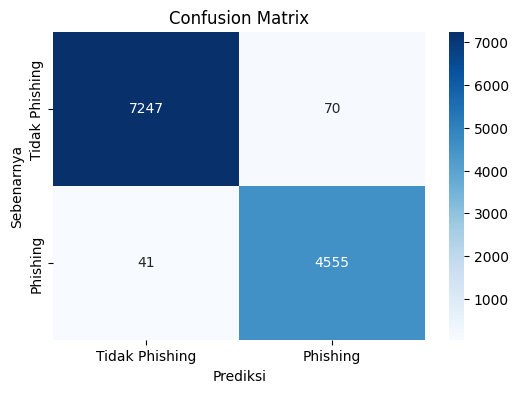

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# evaluasi data train resampled
accuracy = accuracy_score(df_train2['Phishing'], df_train['Predicted']) #mengubah dari train menjadi train_resampled
print("Akurasi Model:", accuracy)
print("Laporan Klasifikasi:\n", classification_report(df_train2['Phishing'], df_train2['Predicted'])) #mengubah dari train menjadi train_resampled

# Confusion Matrix data train
cm = confusion_matrix(df_train2['Phishing'], df_train2['Predicted']) #mengubah dari train menjadi train_resampled
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Tidak Phishing', 'Phishing'], yticklabels=['Tidak Phishing', 'Phishing'])
plt.xlabel('Prediksi')
plt.ylabel('Sebenarnya')
plt.title('Confusion Matrix')
plt.show()


In [ ]:

testnih['Predicted'] = testnih['Message'].apply(predict_naive_bayes)
df_test2 = testnih[['Message', 'Phishing', 'Predicted']]
df_test2

<ipython-input-72-fa1eff26b3cd>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  testnih['Predicted'] = testnih['Message'].apply(predict_naive_bayes)


,Message,Phishing,Predicted
11913,please respond linguistics cd rom mispased idi...,0.0,0
11914,thursday aug pm ralf ertzinger wrote hi john h...,0.0,0
11915,surprise clus available consumer cyerior via c...,1.0,1
11916,claim laptop bait excelled em ca last problem ...,1.0,1
11917,help needed please cross commodity reporting p...,0.0,0
...,...,...,...
14887,give adobe photoshop xp pro norton office xp o...,1.0,1
14888,work home free info need help year old fortune...,1.0,1
14889,enymex brad may consider targeting wide audien...,0.0,0
14890,wip report attached updated wip report week th...,0.0,0


*italicized text*

Akurasi Model: 0.9889224572004028
Laporan Klasifikasi:
               precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      1515
         1.0       0.99      0.99      0.99      1464

    accuracy                           0.99      2979
   macro avg       0.99      0.99      0.99      2979
weighted avg       0.99      0.99      0.99      2979



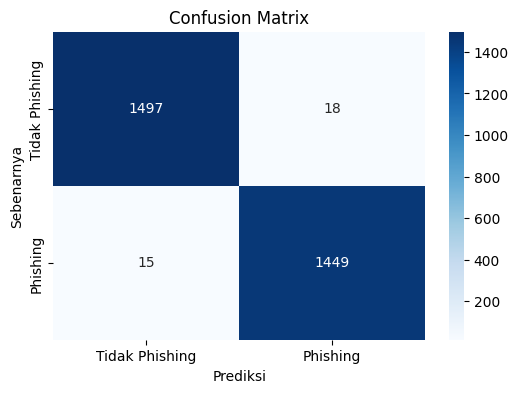

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


accuracy = accuracy_score(df_test['Phishing'], df_test['Predicted'])
print("Akurasi Model:", accuracy)
print("Laporan Klasifikasi:\n", classification_report(df_test['Phishing'], df_test['Predicted']))

cm = confusion_matrix(df_test['Phishing'],df_test['Predicted'])

# Menampilkan confusion matrix dengan seaborn heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Tidak Phishing', 'Phishing'], yticklabels=['Tidak Phishing', 'Phishing'])
plt.xlabel('Prediksi')
plt.ylabel('Sebenarnya')
plt.title('Confusion Matrix')
plt.show()
